<a href="https://colab.research.google.com/github/rizalrfli/PCVK_GANJIL-2026/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Praktikum Filter Spasial
**Acuan:** Modul 6 - Spasial Filter, Pengolahan Citra dan Visi Komputer, JTI Polinema.

**Nama:** Afrizal Rafli Kusuma Wardana  
**NIM:** 24417020007  
**Kelas:** TI 3C

Notebook memuat **Bagian D (konvolusi manual), Bagian E (percobaan 1 sampai 7), dan ketiga Tugas Praktikum**.
Semua foto berasal dari berkas yang dilampirkan. Hasil gambar dan tabel analisis disimpan otomatis.

## Cara menjalankan di Google Colab
1. Buka https://colab.research.google.com, pilih **File > Upload notebook**, lalu unggah `Week7.ipynb`.
2. Gunakan runtime Python 3. CPU cukup; GPU tidak wajib.
3. Pilih **Runtime > Run all / Jalankan semua**. Tiga foto bawaan akan dipulihkan otomatis.
4. Sel terakhir menyediakan tombol unduh ZIP hasil. Jika ingin menyimpan notebook di GitHub, gunakan
   **File > Save a copy in GitHub**, pilih repositori milik Anda, dan isi pesan commit.

Notebook ini telah dijalankan pada runtime Python lokal. Output yang tersimpan adalah hasil eksekusi,
bukan tangkapan layar sesi Colab. Jalankan kembali di akun Colab Anda bila diperlukan bukti sesi pribadi.

## 1 Persiapan library
OpenCV digunakan untuk pembacaan citra dan Bagian E/Tugas. **Fungsi konvolusi Bagian D tidak memanggil
`filter2D`, `convolve`, atau metode konvolusi library.** NumPy hanya digunakan untuk array, padding,
perkalian elemen, dan penjumlahan.

In [ ]:
import sys, subprocess, importlib.util
from pathlib import Path
import base64, hashlib, io, json, math, time, zipfile

for module, package in [('cv2', 'opencv-contrib-python-headless==4.12.0.88'),
                        ('torch', 'torch')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from IPython.display import display, Markdown

get_ipython().run_line_magic('matplotlib', 'inline')
plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white'})
np.set_printoptions(precision=4, suppress=True)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
WORK = Path('/content') if IN_COLAB else Path.cwd()
BASE = WORK / 'praktikum_filter_data'
HASIL = WORK / 'hasil_filter'
BASE.mkdir(exist_ok=True)
HASIL.mkdir(exist_ok=True)
print('Python:', sys.version.split()[0])
print('NumPy:', np.__version__, '| OpenCV:', cv.__version__, '| PyTorch:', torch.__version__)
print('Folder hasil:', HASIL.name)

Python: 3.12.14
NumPy: 2.2.6 | OpenCV: 4.12.0 | PyTorch: 2.6.0+cpu
Folder hasil: hasil_filter


## 2 Memulihkan foto yang sesuai modul

| Foto | Ukuran asli | Pemakaian |
|---|---|---|
| `mandrill.tiff` | 512 x 512 | Konvolusi manual dan delapan kernel Bagian D |
| `lena (1).jpg` | 512 x 512 | Percobaan 1 sampai 5 serta Tugas 1 sampai 3 |
| `djawatan.jpg` | 1080 x 720 | Percobaan 6 dan 7 |

Sel berikut menyertakan ketiga berkas asli sebagai ZIP terenkode; kodenya dilipat di Colab.
Nama `lena (1).jpg` sengaja dipertahankan sesuai lampiran.

In [ ]:
# @title Pulihkan tiga foto bawaan { display-mode: "form" }
FOTO_ZIP_B64 = '...'
HASH_FOTO = {'mandrill.tiff': '3f590b52279fb59b81906f1e928ae713a5357b1afc1a2017a103adb563fb4494', 'lena (1).jpg': 'eceec281c065ebf712628d33806df62ee12e9d876d038d426c9e8221982ea8f0', 'djawatan.jpg': 'edc4bb9422581fb306b3118385286783f570cd15794013f7dbb5b262f6167aa7'}
with zipfile.ZipFile(io.BytesIO(base64.b64decode(FOTO_ZIP_B64))) as z:
    for name in HASH_FOTO:
        data = z.read(name)
        assert hashlib.sha256(data).hexdigest() == HASH_FOTO[name], name
        (BASE / name).write_bytes(data)
del FOTO_ZIP_B64
print('Tiga foto bawaan dipulihkan dan integritas SHA256 sesuai.')

Tiga foto bawaan dipulihkan dan integritas SHA256 sesuai.


mandrill.tiff -> (512, 512, 3) | dtype uint8
lena (1).jpg -> (512, 512, 3) | dtype uint8
djawatan.jpg -> (720, 1080, 3) | dtype uint8


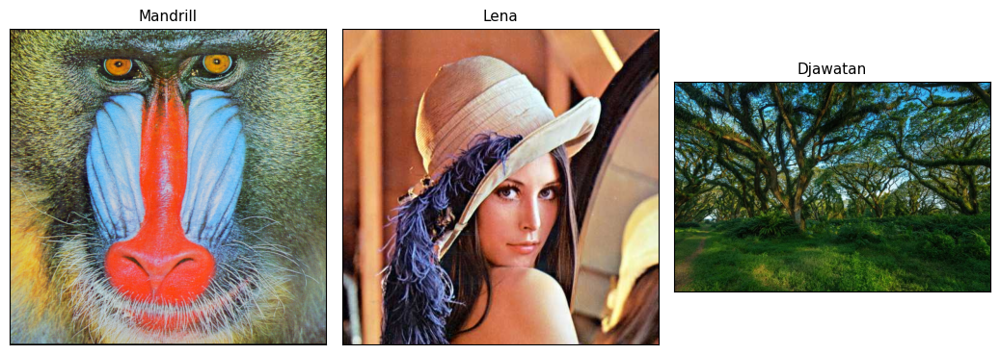

In [ ]:
def baca_foto(nama):
    # imdecode juga menghindari masalah nama berkas dengan spasi.
    image = cv.imdecode(np.frombuffer((BASE / nama).read_bytes(), dtype=np.uint8), cv.IMREAD_COLOR)
    if image is None:
        raise ValueError(f'Gambar tidak dapat dibaca: {nama}')
    return image

mandrill = baca_foto('mandrill.tiff')
lena = baca_foto('lena (1).jpg')
djawatan = baca_foto('djawatan.jpg')
mandrill_gray = cv.cvtColor(mandrill, cv.COLOR_BGR2GRAY)
lena_gray = cv.cvtColor(lena, cv.COLOR_BGR2GRAY)

def u8(image):
    return np.clip(np.rint(image), 0, 255).astype(np.uint8)

def simpan_foto(nama, image):
    cv.imwrite(str(HASIL / nama), u8(image))

def show_side_by_side(images, titles, filename, ncols=None, auto=False, row_labels=None):
    ncols = ncols or len(images)
    rows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(rows, ncols, figsize=(3.5*ncols, 3.65*rows), squeeze=False)
    for ax, image, title in zip(axes.flat, images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap='gray', **({} if auto else {'vmin': 0, 'vmax': 255}))
        else:
            ax.imshow(cv.cvtColor(u8(image), cv.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in list(axes.flat)[len(images):]:
        ax.axis('off')
    if row_labels:
        for ax, label in zip(axes[:, 0], row_labels):
            ax.set_ylabel(label, fontsize=11)
    fig.tight_layout()
    fig.savefig(HASIL / filename, dpi=170, bbox_inches='tight')
    plt.show()
    plt.close(fig)

def tabel_markdown(headers, rows):
    def fmt(value):
        return f'{value:.4f}' if isinstance(value, (float, np.floating)) else str(value)
    lines = ['| '+' | '.join(headers)+' |', '| '+' | '.join(['---']*len(headers))+' |']
    lines += ['| '+' | '.join(fmt(x) for x in row)+' |' for row in rows]
    display(Markdown('\n'.join(lines)))

show_side_by_side([mandrill, lena, djawatan], ['Mandrill', 'Lena', 'Djawatan'], '00_foto_asli.png')
for name, image in [('mandrill.tiff',mandrill),('lena (1).jpg',lena),('djawatan.jpg',djawatan)]:
    print(name, '->', image.shape, '| dtype', image.dtype)
RINGKASAN = {'foto': HASH_FOTO, 'versi': {'python': sys.version.split()[0],
            'numpy': np.__version__, 'opencv': cv.__version__, 'torch': torch.__version__}}

# D Praktikum filter dengan konvolusi manual
## D1 Fungsi konvolusi
Setiap jendela piksel dikalikan dengan kernel, kemudian dijumlahkan. `padding='same'` dan
`stride=1` mempertahankan ukuran citra. Padding refleksi mengurangi perubahan gelap pada batas citra.

**Konvensi:** contoh algoritma modul tidak membalik kernel. Karena itu, nilai default
`flip_kernel=False` mengikuti **korelasi silang** yang juga dipakai `cv.filter2D`.
Pilih `flip_kernel=True` untuk konvolusi matematis dengan pembalikan 180 derajat.
Pada kernel simetris, keduanya sama; pada Sobel/Emboss yang asimetris, arahnya dapat berbeda.
Perhitungan menggunakan `float64`, supaya nilai negatif atau di atas 255 tidak mengalami overflow.

In [ ]:
def convolution2d(image, kernel, stride=1, padding='same', border='reflect', flip_kernel=False):
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)
    if image.ndim != 2 or kernel.ndim != 2:
        raise ValueError('Citra dan kernel harus berupa matriks 2D.')
    kh, kw = kernel.shape
    if kh % 2 == 0 or kw % 2 == 0 or stride < 1:
        raise ValueError('Ukuran kernel harus ganjil dan stride minimal 1.')
    if padding == 'same':
        ph, pw = kh // 2, kw // 2
    elif padding == 'valid':
        ph, pw = 0, 0
    elif isinstance(padding, int) and padding >= 0:
        ph, pw = padding, padding
    else:
        raise ValueError('Gunakan padding same, valid, atau bilangan >= 0.')
    if flip_kernel:
        kernel = kernel[::-1, ::-1]
    padded = np.pad(image, ((ph, ph), (pw, pw)), mode=border)
    oh = (padded.shape[0] - kh) // stride + 1
    ow = (padded.shape[1] - kw) // stride + 1
    if min(oh, ow) < 1:
        raise ValueError('Kernel terlalu besar untuk citra dengan padding ini.')
    output = np.zeros((oh, ow), dtype=np.float64)
    for y in range(oh):
        for x in range(ow):
            patch = padded[y*stride:y*stride+kh, x*stride:x*stride+kw]
            output[y, x] = np.sum(patch * kernel)
    return output

# Perhitungan tangan yang membedakan korelasi silang dan konvolusi.
contoh = np.arange(1, 10, dtype=float).reshape(3, 3)
kernel_arah = np.array([[1,0,0],[0,0,0],[0,0,-1]], dtype=float)
assert convolution2d(contoh, kernel_arah, padding='valid')[0,0] == -8
assert convolution2d(contoh, kernel_arah, padding='valid', flip_kernel=True)[0,0] == 8
print('Contoh tangan lulus: korelasi = 1 - 9 = -8; konvolusi = 9 - 1 = 8.')

Contoh tangan lulus: korelasi = 1 - 9 = -8; konvolusi = 9 - 1 = 8.


## D2 Kernel sesuai modul
Average, Low Pass, High Pass, Sharpen, Emboss, Left Sobel, kernel berlabel Canny pada modul,
dan Gaussian 21 x 21 semuanya diproses oleh fungsi manual.

**Catatan Canny:** matriks dengan pusat 8 dan delapan tetangga -1 adalah kernel
**Laplacian 8 tetangga**, bukan algoritma Canny. Matriks tetap diterapkan sesuai modul.
Canny yang sebenarnya digunakan pada Percobaan 1 melalui `cv.Canny`.
Untuk Gaussian 21 x 21, `getGaussianKernel` hanya membuat koefisien;
proses penyaringannya tetap dilakukan fungsi manual.

Average 3 x 3 | ukuran (3, 3) | jumlah koefisien 1.0
[[0.1111 0.1111 0.1111]
 [0.1111 0.1111 0.1111]
 [0.1111 0.1111 0.1111]]
Low Pass | ukuran (3, 3) | jumlah koefisien 1.0
[[0.0833 0.0833 0.0833]
 [0.0833 0.3333 0.0833]
 [0.0833 0.0833 0.0833]]
High Pass | ukuran (3, 3) | jumlah koefisien 0.0
[[-1  0  1]
 [-1  0  3]
 [-3  0  1]]
Sharpen | ukuran (3, 3) | jumlah koefisien 1.0
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]
Emboss | ukuran (3, 3) | jumlah koefisien 1.0
[[-2 -1  0]
 [-1  1  1]
 [ 0  1  2]]
Left Sobel | ukuran (3, 3) | jumlah koefisien 0.0
[[ 1  0 -1]
 [ 2  0 -2]
 [ 1  0 -1]]
Laplacian 8 (label Canny modul) | ukuran (3, 3) | jumlah koefisien 0.0
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]
Gaussian 21 x 21 | ukuran (21, 21) | jumlah koefisien 1.0
Visualisasi memakai clip 0 sampai 255; nilai raw bertanda disimpan sebagai .npy.


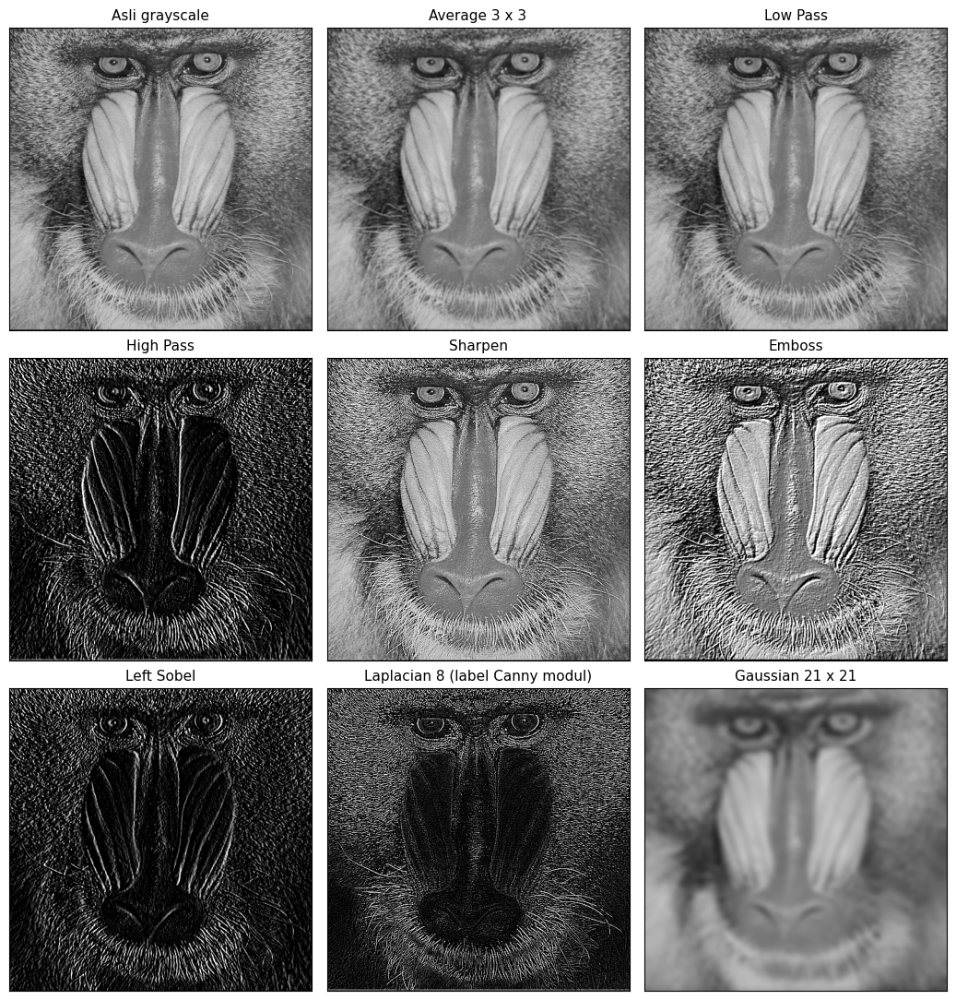

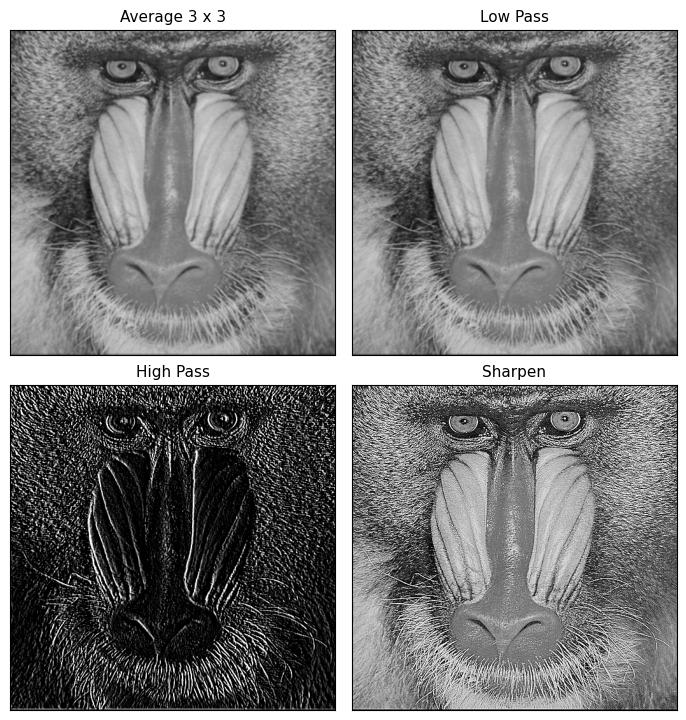

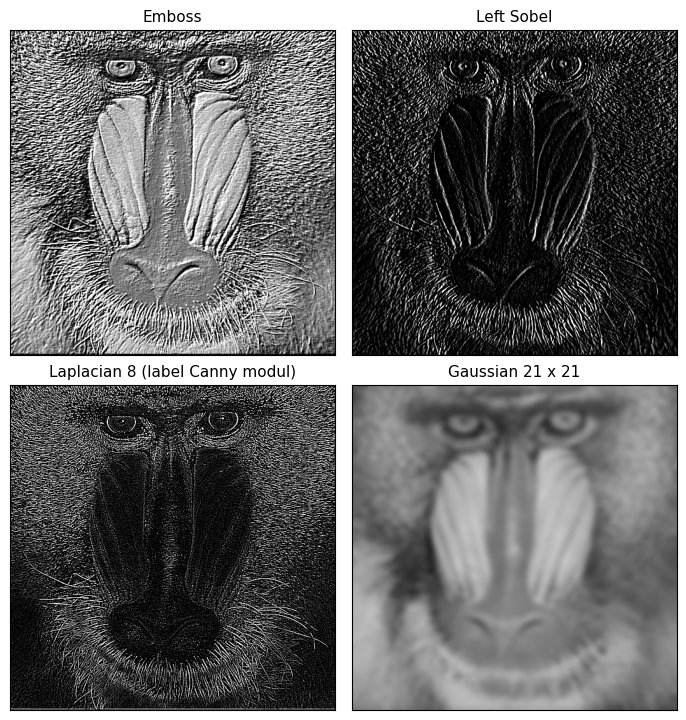

| Filter | Minimum raw | Maksimum raw | Waktu detik |
| --- | --- | --- | --- |
| Average 3 x 3 | 11.5556 | 211.1111 | 0.9047 |
| Low Pass | 10.6667 | 212.0833 | 0.9297 |
| High Pass | -808.0000 | 801.0000 | 0.9350 |
| Sharpen | -395.0000 | 623.0000 | 0.8538 |
| Emboss | -548.0000 | 867.0000 | 0.8507 |
| Left Sobel | -627.0000 | 663.0000 | 0.8767 |
| Laplacian 8 (label Canny modul) | -1164.0000 | 985.0000 | 0.8810 |
| Gaussian 21 x 21 | 38.7687 | 198.7432 | 0.9800 |

In [ ]:
g1 = cv.getGaussianKernel(21, math.sqrt(21))
kernels = {
    'Average 3 x 3': np.ones((3,3)) / 9,
    'Low Pass': np.array([[1,1,1],[1,4,1],[1,1,1]]) / 12,
    'High Pass': np.array([[-1,0,1],[-1,0,3],[-3,0,1]]),
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    'Emboss': np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),
    'Left Sobel': np.array([[1,0,-1],[2,0,-2],[1,0,-1]]),
    'Laplacian 8 (label Canny modul)': np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]]),
    'Gaussian 21 x 21': g1 @ g1.T,
}
for name, kernel in kernels.items():
    print(name, '| ukuran', kernel.shape, '| jumlah koefisien', round(float(kernel.sum()), 6))
    if kernel.shape == (3,3):
        print(kernel)

manual_raw, manual_view, waktu_manual = {}, {}, {}
for i, (name, kernel) in enumerate(kernels.items(), 1):
    mulai = time.perf_counter()
    raw = convolution2d(mandrill_gray, kernel)
    waktu_manual[name] = time.perf_counter() - mulai
    manual_raw[name] = raw
    manual_view[name] = u8(raw)
    np.save(HASIL / f'D_{i:02d}_raw.npy', raw)
    simpan_foto(f'D_{i:02d}.png', manual_view[name])
nama_filter = list(kernels)
show_side_by_side([mandrill_gray] + list(manual_view.values()),
    ['Asli grayscale'] + nama_filter, 'D_semua_filter.png', ncols=3)
show_side_by_side([manual_view[n] for n in nama_filter[:4]], nama_filter[:4],
                 'D_filter_1.png', ncols=2)
show_side_by_side([manual_view[n] for n in nama_filter[4:]], nama_filter[4:],
                 'D_filter_2.png', ncols=2)
tabel_markdown(['Filter','Minimum raw','Maksimum raw','Waktu detik'],
    [[n, float(manual_raw[n].min()), float(manual_raw[n].max()), waktu_manual[n]] for n in nama_filter])
print('Visualisasi memakai clip 0 sampai 255; nilai raw bertanda disimpan sebagai .npy.')

**Pembahasan D:** Average meratakan nilai tetangga, sedangkan Low Pass memberi bobot lebih besar
pada piksel pusat sehingga detail lebih terjaga. Sharpen mempertajam transisi intensitas.
High Pass dan Left Sobel menonjolkan perubahan yang berarah. Emboss menghasilkan kesan relief.
Laplacian bereaksi terhadap perubahan intensitas dari banyak arah. Gaussian 21 x 21 memberikan
pengaburan paling luas. Clipping tampilan mengubah respons negatif menjadi hitam; berkas `raw.npy`
tetap mempertahankan respons bertanda untuk analisis.

## D3 Validasi implementasi manual
Pengujian berikut ditempatkan **setelah** praktikum manual. OpenCV hanya menjadi pembanding numerik,
bukan bagian dari implementasi fungsi manual. Semua kernel diuji pada potongan Mandrill 64 x 64
dengan jenis border dan konvensi kernel yang sama.

In [ ]:
validasi = []
patch_uji = mandrill_gray[:64,:64].astype(np.float64)
for name, kernel in kernels.items():
    manual = convolution2d(patch_uji, kernel)
    acuan = cv.filter2D(patch_uji, cv.CV_64F, kernel.astype(np.float64),
                       borderType=cv.BORDER_REFLECT_101)
    error = float(np.max(np.abs(manual-acuan)))
    assert np.allclose(manual, acuan, atol=1e-8, rtol=1e-8), name
    validasi.append([name, error, 'Lulus'])
assert convolution2d(patch_uji, np.ones((3,3))/9, stride=2).shape == (32,32)
assert convolution2d(patch_uji, np.ones((3,3))/9, padding='valid').shape == (62,62)
tabel_markdown(['Kernel','Error maksimum','Status'],validasi)
RINGKASAN['manual'] = {'validasi':validasi, 'waktu_detik':waktu_manual,
                      'ukuran_output':list(mandrill_gray.shape)}

| Kernel | Error maksimum | Status |
| --- | --- | --- |
| Average 3 x 3 | 0.0000 | Lulus |
| Low Pass | 0.0000 | Lulus |
| High Pass | 0.0000 | Lulus |
| Sharpen | 0.0000 | Lulus |
| Emboss | 0.0000 | Lulus |
| Left Sobel | 0.0000 | Lulus |
| Laplacian 8 (label Canny modul) | 0.0000 | Lulus |
| Gaussian 21 x 21 | 0.0000 | Lulus |

# E Filter library dan filter modern
## Percobaan 1 Gaussian Sharpen dan Canny
Foto Lena dipertahankan dalam warna BGR untuk Gaussian dan Sharpen, kemudian dikonversi ke RGB
saat ditampilkan. Canny menerima citra grayscale dan menghasilkan peta tepi biner.

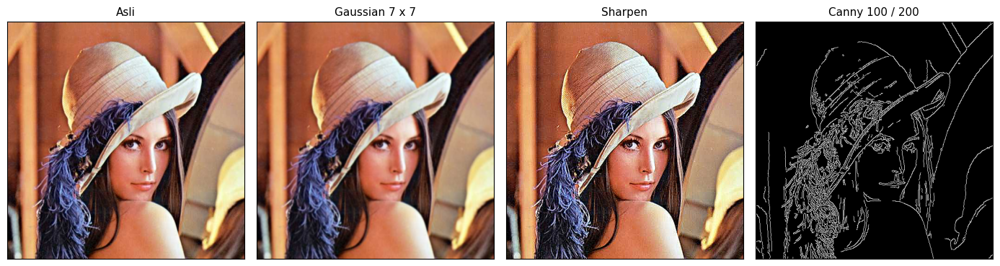

In [ ]:
blur = cv.GaussianBlur(lena, (7,7), 1)
sharpened = cv.filter2D(lena, -1, kernels['Sharpen'])
edges_canny = cv.Canny(lena_gray, 100, 200)
show_side_by_side([lena, blur, sharpened, edges_canny],
    ['Asli', 'Gaussian 7 x 7', 'Sharpen', 'Canny 100 / 200'], 'E1_library.png', ncols=4)
for name, img in [('E1_gaussian.png',blur),('E1_sharpen.png',sharpened),('E1_canny.png',edges_canny)]:
    simpan_foto(name,img)

**Pembahasan:** Gaussian melembutkan detail wajah dan tekstur topi. Sharpen meningkatkan
kontras lokal, termasuk tekstur dan noise. Canny menampilkan garis batas tipis, sehingga hasilnya
berbeda dari respons intensitas kernel Laplacian pada Bagian D.

## Percobaan 2 Bilateral dan penyaringan yang menjaga tepi
Kode modul memakai `edgePreservingFilter` sebagai alternatif Guided Filter; kedua nama ini
tidak menunjuk algoritma yang sama. Di sini hasil modul disertakan, ditambah **Guided Filter yang sebenarnya**.
Jika modul contrib OpenCV tidak tersedia, rumus Guided Filter menggunakan citra pemandu grayscale
diterapkan melalui rata-rata lokal. Bagian D tidak menggunakan fungsi-fungsi ini.

Implementasi Guided Filter: OpenCV ximgproc dengan guide warna


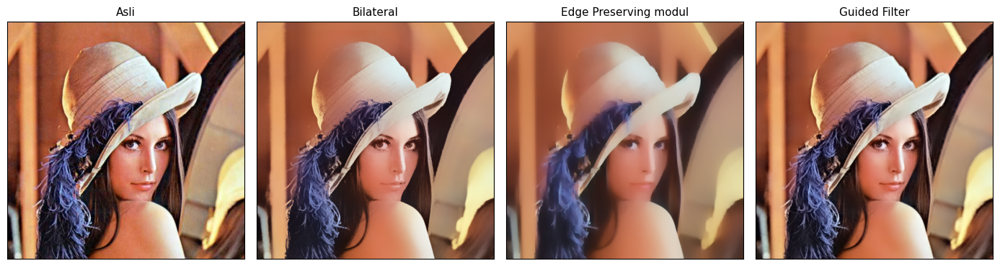

In [ ]:
bilateral = cv.bilateralFilter(lena, 50, 100, 100)
edge_preserve = cv.edgePreservingFilter(lena, flags=1, sigma_s=100, sigma_r=0.9)

def guided_filter(image, radius=8, eps=0.01):
    p = image.astype(np.float32) / 255.0
    if hasattr(cv, 'ximgproc') and hasattr(cv.ximgproc, 'guidedFilter'):
        return u8(cv.ximgproc.guidedFilter(p, p, radius, eps) * 255), 'OpenCV ximgproc dengan guide warna'
    # Guided Filter asli dengan guide grayscale, bukan edgePreservingFilter.
    guide = cv.cvtColor(image, cv.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    size = (2*radius+1, 2*radius+1)
    mean = lambda a: cv.boxFilter(a, cv.CV_32F, size, borderType=cv.BORDER_REFLECT_101)
    mi = mean(guide)
    variance = mean(guide*guide) - mi*mi
    result = np.empty_like(p)
    for c in range(3):
        mp = mean(p[:,:,c])
        covariance = mean(guide*p[:,:,c]) - mi*mp
        a = covariance/(variance+eps)
        b = mp-a*mi
        result[:,:,c] = mean(a)*guide + mean(b)
    return u8(result*255), 'Rumus Guided Filter dengan guide grayscale'

guided, guided_impl = guided_filter(lena)
print('Implementasi Guided Filter:', guided_impl)
show_side_by_side([lena, bilateral, edge_preserve, guided],
   ['Asli', 'Bilateral', 'Edge Preserving modul', 'Guided Filter'], 'E2_modern.png', ncols=4)
RINGKASAN['guided_implementation'] = guided_impl

**Pembahasan:** Bilateral mempertimbangkan jarak piksel dan kemiripan intensitas.
Area datar lebih rata, sementara batas wajah dan topi relatif terjaga.
Edge Preserving menggunakan parameter modul yang kuat sehingga penghalusan tampak lebih besar.
Guided Filter mempertahankan struktur citra pemandu; kekuatan hasil bergantung pada radius dan epsilon.
Perbedaan hasil bukan hanya nama filter, tetapi juga parameter dan citra pemandu.

## Percobaan 3 Feature map pada CNN dan pengulangan eksekusi
Arsitektur mengikuti modul: `Conv2d(1,4,kernel_size=3,stride=1,padding=1)` tanpa pelatihan.
Setiap model baru mendapat bobot awal acak. Tiga seed digunakan agar perbandingan dapat diulang.

Ukuran input: (1, 1, 512, 512) | ukuran keluaran: (1, 4, 512, 512)
Error seed sama: 0.0 | error model sama: 0.0
Mean absolute difference seed 7 vs 42: 0.689475


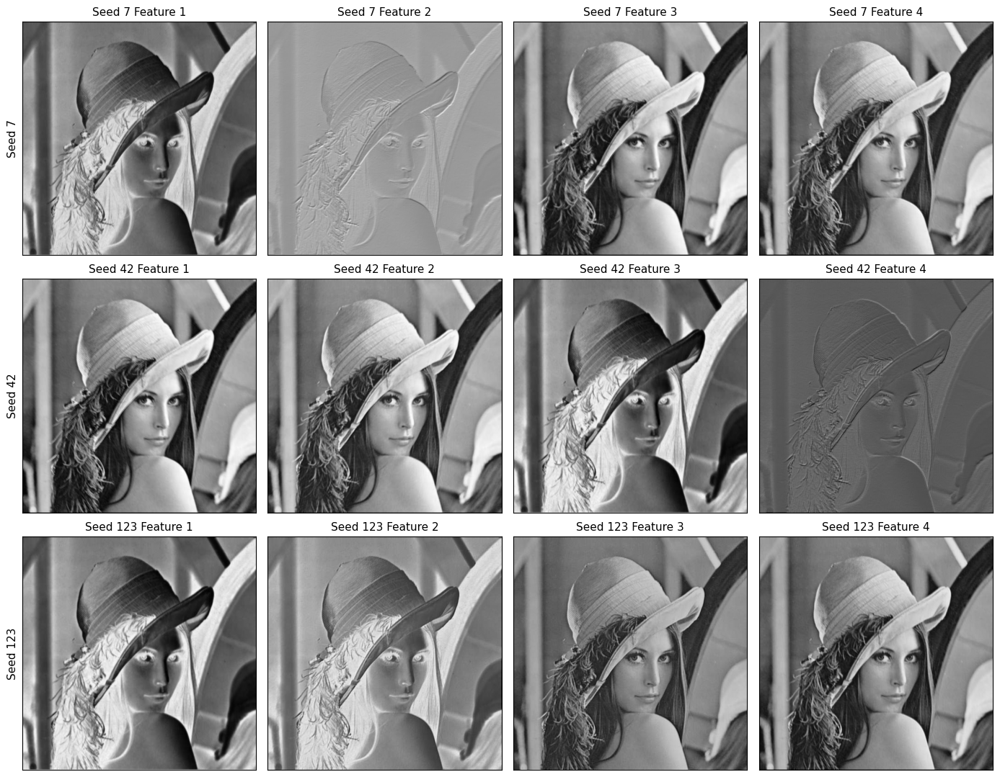

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
        return self.conv1(x)

img_tensor = torch.tensor(lena_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
fitur_seed = {}
for seed in [7,42,123]:
    torch.manual_seed(seed)
    model = SimpleCNN().eval()
    with torch.no_grad():
        features = model(img_tensor).cpu().numpy()[0]
    fitur_seed[seed] = features
    np.save(HASIL / f'E3_features_seed_{seed}.npy', features)
show_side_by_side([f for s in fitur_seed for f in fitur_seed[s]],
     [f'Seed {s} Feature {i+1}' for s in fitur_seed for i in range(4)],
     'E3_cnn_seed.png', ncols=4, auto=True, row_labels=['Seed 7','Seed 42','Seed 123'])
print('Ukuran input:', tuple(img_tensor.shape), '| ukuran keluaran:', (1,*features.shape))

# Dengan seed tetap, inisialisasi dan hasilnya dapat diulang.
torch.manual_seed(42)
model_tetap = SimpleCNN().eval()
with torch.no_grad():
    ulang1 = model_tetap(img_tensor).cpu().numpy()[0]
    ulang2 = model_tetap(img_tensor).cpu().numpy()[0]
error_seed_tetap = float(np.max(np.abs(ulang1-fitur_seed[42])))
error_model_tetap = float(np.max(np.abs(ulang1-ulang2)))
beda_seed = float(np.mean(np.abs(fitur_seed[7]-fitur_seed[42])))
assert error_seed_tetap == 0 and error_model_tetap == 0
print('Error seed sama:',error_seed_tetap,'| error model sama:',error_model_tetap)
print('Mean absolute difference seed 7 vs 42:',round(beda_seed,6))
RINGKASAN['cnn'] = {'input_shape':list(img_tensor.shape), 'output_shape':[1,*features.shape],
    'beda_seed_7_42':beda_seed, 'error_seed_tetap':error_seed_tetap, 'error_model_tetap':error_model_tetap}

**Kesimpulan Percobaan 3:** model yang diinisialisasi kembali dengan seed berbeda menghasilkan
peta fitur berbeda. Jika bobot model yang sama digunakan kembali, hasil tidak berubah.
Seed tetap menghasilkan inisialisasi yang sama. Empat saluran merespons intensitas/tekstur secara
berbeda, tetapi **belum dapat disebut mendeteksi fitur bermakna hasil pembelajaran**, karena model
belum dilatih. Setiap panel feature map dinormalisasi tampilannya secara terpisah oleh Matplotlib;
nilai tensor aslinya disimpan dalam `.npy`.

## Percobaan 4 Beauty dan Vintage
Beauty: Bilateral, unsharp masking, kemudian penyesuaian kontras dan kecerahan.
Vintage: warna sepia, vignette, dan grain. Noise grain menggunakan seed tetap.

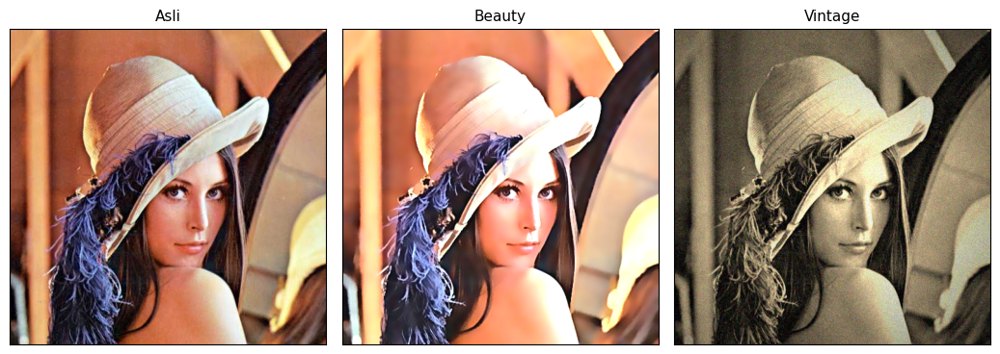

In [ ]:
smooth = cv.bilateralFilter(lena, d=15, sigmaColor=75, sigmaSpace=75)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
beauty_sharp = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)
beauty = cv.convertScaleAbs(beauty_sharp, alpha=1.2, beta=15)

sepia_kernel = np.array([[0.272,0.534,0.131], [0.349,0.686,0.168], [0.393,0.769,0.189]],np.float32)
sepia = u8(cv.transform(lena.astype(np.float32), sepia_kernel))
rows, cols = lena.shape[:2]
kx = cv.getGaussianKernel(cols, cols*0.6)
ky = cv.getGaussianKernel(rows, rows*0.6)
mask = ky @ kx.T
mask = mask / mask.max()
vignette = sepia.astype(np.float32) * mask[:,:,None]
grain = np.random.default_rng(2026).normal(0,15,lena.shape)
vintage = u8(vignette + grain)
show_side_by_side([lena,beauty,vintage], ['Asli','Beauty','Vintage'], 'E4_beauty_vintage.png')

**Pembahasan:** Beauty menghaluskan tekstur dan mencerahkan seluruh foto; kode ini tidak mendeteksi
kulit, mata, atau bibir secara khusus. Vintage menghasilkan nuansa cokelat, sudut lebih gelap,
dan butiran gambar. Efek ini merupakan kombinasi filter tradisional, bukan GenAI.

## Percobaan 5 Anime atau Cartoon
Penghalusan warna dilakukan dengan Bilateral. Median pada grayscale membantu menstabilkan
garis sebelum Adaptive Threshold. Masker tepi digabungkan dengan citra warna.

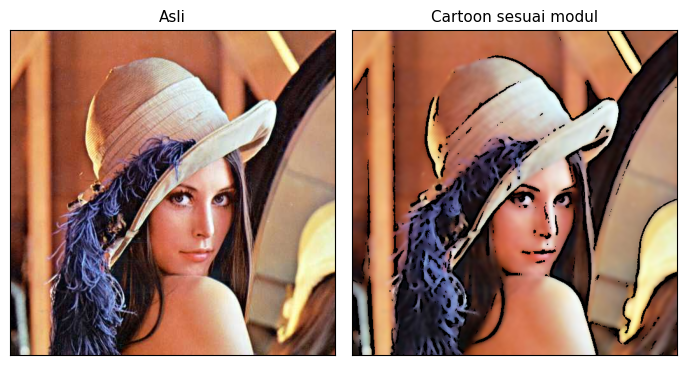

In [ ]:
gray_blur = cv.medianBlur(lena_gray, 7)
cartoon_edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C,
                                    cv.THRESH_BINARY, 9, 9)
cartoon_color = cv.bilateralFilter(lena, d=9, sigmaColor=200, sigmaSpace=200)
cartoon_modul = cv.bitwise_and(cartoon_color, cartoon_color, mask=cartoon_edges)
show_side_by_side([lena,cartoon_modul],['Asli','Cartoon sesuai modul'],'E5_cartoon.png')

**Pembahasan:** warna menjadi lebih rata dan area bermasker nol membentuk garis hitam.
Tekstur bulu pada topi masih dapat membentuk detail kecil, sehingga hasilnya menyerupai kartun
dengan garis foto asli, bukan ilustrasi anime hasil generasi model.

## Percobaan 6 Filter malam
Foto diganti menjadi `djawatan.jpg` sebagaimana modul. Hasil versi modul disimpan.
Penambahan ini juga menampilkan versi yang menjepit nilai negatif ke nol untuk penggelapan yang konsisten.

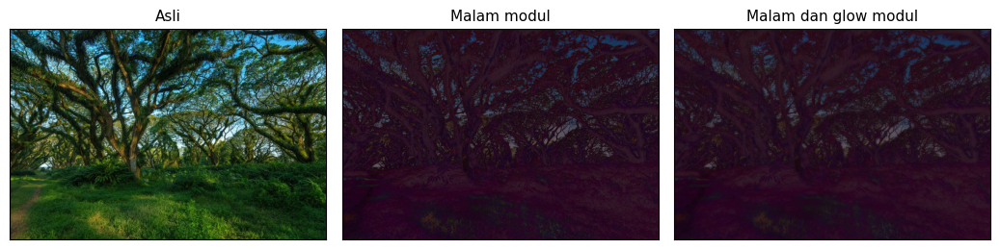

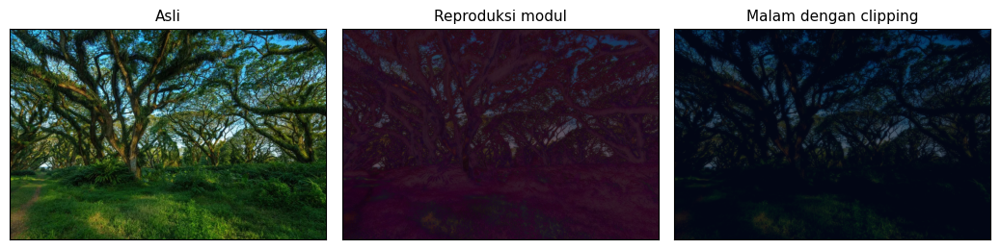

In [ ]:
# Reproduksi parameter dan operasi modul.
night = cv.convertScaleAbs(djawatan, alpha=0.6, beta=-40)
blue_tint = np.full_like(night, (50,0,100))  # urutan BGR sesuai modul
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)
glow_kernel = np.ones((15,15),np.float32)/225
glow = cv.filter2D(night,-1,glow_kernel)
nightglow = cv.addWeighted(night,0.7,glow,0.3,0)
show_side_by_side([djawatan,night,nightglow],
    ['Asli','Malam modul','Malam dan glow modul'],'E6_malam_modul.png')

# convertScaleAbs menggunakan nilai absolut; untuk beta negatif gunakan clipping.
night_clip = u8(djawatan.astype(float)*0.6-40)
true_blue = np.full_like(night_clip,(100,30,10))  # B lebih besar daripada R
night_clip = cv.addWeighted(night_clip,0.8,true_blue,0.2,0)
glow_clip = cv.filter2D(night_clip,-1,glow_kernel)
nightglow_clip = cv.addWeighted(night_clip,0.7,glow_clip,0.3,0)
show_side_by_side([djawatan,nightglow,nightglow_clip],
    ['Asli','Reproduksi modul','Malam dengan clipping'],'E6_malam_koreksi.png')

**Pembahasan:** brightness dan contrast diturunkan sehingga suasana tampak lebih gelap;
blur 15 x 15 dan blending melembutkan bagian terang. Pada `convertScaleAbs`, nilai negatif
diubah menjadi absolut, bukan menjadi nol. Selain itu, `(50,0,100)` dalam BGR lebih besar pada
saluran merah daripada biru. Karena itu versi koreksi dipisahkan dan diberi nama yang jelas.

## Percobaan 7 Filter pagi dan kabut
Parameter mengikuti contoh modul. Gaussian 3 x 3 melunakkan detail, lalu lapisan putih
dengan bobot 0.3 memberi tampilan kabut.

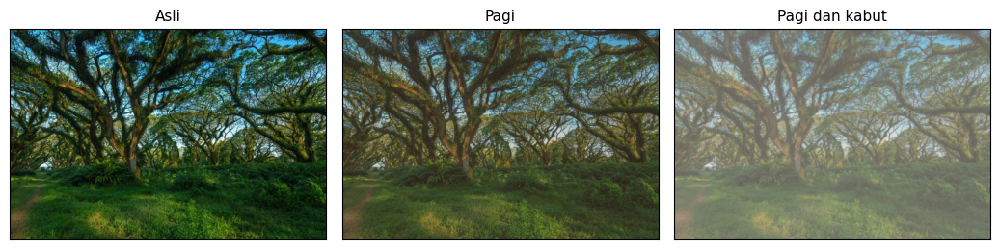

In [ ]:
soft = cv.convertScaleAbs(djawatan,alpha=0.9,beta=20)
warm_tint = np.full_like(soft,(40,70,120))
pagi = cv.addWeighted(soft,0.8,warm_tint,0.2,0)
kg = cv.getGaussianKernel(3,3)
kabut = cv.filter2D(pagi,-1,kg @ kg.T)
white_layer = np.full_like(pagi,255)
kabut = cv.addWeighted(kabut,0.7,white_layer,0.3,0)
show_side_by_side([djawatan,pagi,kabut],['Asli','Pagi','Pagi dan kabut'],'E7_pagi_kabut.png')

**Pembahasan:** perubahan tone menghasilkan kesan pagi yang lebih hangat. Penambahan putih
meningkatkan intensitas dan mengurangi kontras detail, sehingga pohon tampak tertutup kabut tipis.
Efek ini merupakan simulasi visual; pencahayaan fisik dan kedalaman pemandangan tidak dihitung.

# Tugas Praktikum
## Tugas 1 Mean dan Median pada noise salt and pepper
Tambahkan noise pada 5 persen posisi piksel unik: setengah hitam dan setengah putih.
Seed 2026 membuat posisi noise dapat diulang. Mean dan Median menggunakan jendela 3 x 3.
MSE yang lebih rendah dan PSNR yang lebih tinggi menandakan hasil lebih dekat ke citra bersih.

Posisi piksel diberi noise: 13107 / 262144


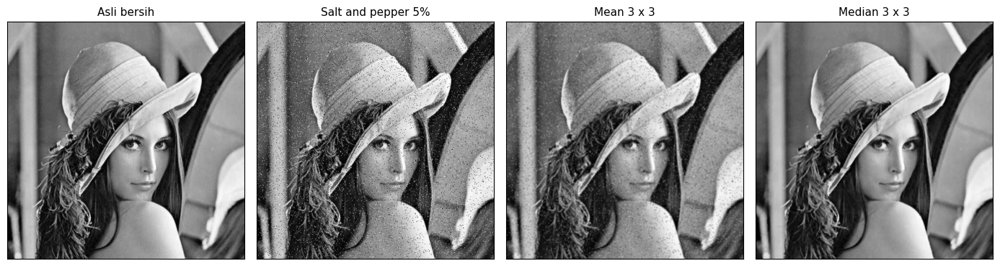

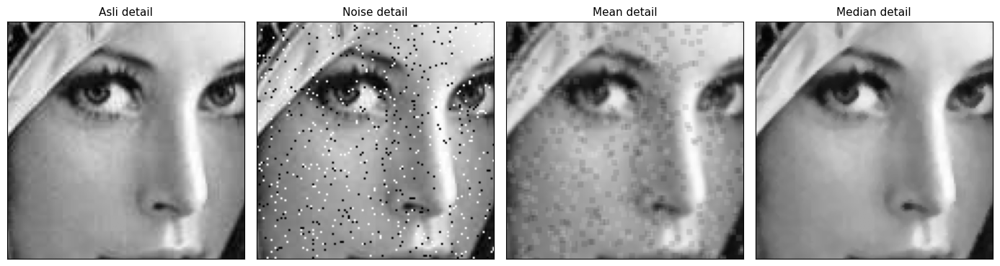

| Kondisi | MSE | PSNR dB |
| --- | --- | --- |
| Noisy 5 persen | 1009.6678 | 18.0890 |
| Mean 3 x 3 | 166.5943 | 25.9142 |
| Median 3 x 3 | 31.4809 | 33.1503 |

In [ ]:
def salt_and_pepper(image, amount=0.05, seed=2026):
    out = image.copy()
    rng = np.random.default_rng(seed)
    n = int(round(amount*image.size))
    pos = rng.choice(image.size,size=n,replace=False)
    out.flat[pos[:n//2]] = 0
    out.flat[pos[n//2:]] = 255
    return out, n

def mse_psnr(reference, result):
    mse = float(np.mean((reference.astype(float)-result.astype(float))**2))
    psnr = float('inf') if mse == 0 else 10*np.log10(255**2/mse)
    return mse,float(psnr)

noisy, jumlah_noisy = salt_and_pepper(lena_gray)
mean3 = cv.blur(noisy,(3,3))
median3 = cv.medianBlur(noisy,3)
noise_rows = []
for name,img in [('Noisy 5 persen',noisy),('Mean 3 x 3',mean3),('Median 3 x 3',median3)]:
    mse,psnr = mse_psnr(lena_gray,img)
    noise_rows.append([name,mse,psnr])
show_side_by_side([lena_gray,noisy,mean3,median3],
    ['Asli bersih','Salt and pepper 5%','Mean 3 x 3','Median 3 x 3'],'T1_noise.png',ncols=4)
crop = (slice(230,350),slice(220,340))
show_side_by_side([im[crop] for im in [lena_gray,noisy,mean3,median3]],
    ['Asli detail','Noise detail','Mean detail','Median detail'],'T1_noise_detail.png',ncols=4)
tabel_markdown(['Kondisi','MSE','PSNR dB'],noise_rows)
print('Posisi piksel diberi noise:',jumlah_noisy,'/',lena_gray.size)
RINGKASAN['tugas1']={'jumlah_posisi_noise':jumlah_noisy,
                     'persen_posisi':100*jumlah_noisy/lena_gray.size,'hasil':noise_rows}

**Jawaban Tugas 1:** Mean memasukkan nilai ekstrem 0/255 ke dalam rata-rata. Satu bintik dapat
memengaruhi banyak jendela sehingga noise menyebar menjadi bercak abu-abu dan detail ikut kabur.
Median memilih nilai tengah dari sembilan piksel. Jika sebagian besar tetangga tidak rusak,
nilai tengah biasanya berasal dari piksel normal, sehingga bintik ekstrem lebih mudah hilang.
Median menghasilkan MSE lebih kecil dan PSNR lebih tinggi pada percobaan ini. Median masih dapat
menghilangkan detail sangat tipis dan tidak dijamin sempurna pada noise yang sangat padat.

## Tugas 2 Evaluasi kernel Sharpen 3 x 3 dan 5 x 5
Agar perbandingannya adil, kedua kernel menggunakan **unsharp masking dengan alpha=1**:
`K = (1+alpha)*identitas - alpha*average(n)`.
Koefisien dijumlahkan menjadi 1 pada kedua ukuran, sehingga brightness rata-rata tidak dinaikkan
hanya karena ukuran kernel berubah. K3 berpiksel pusat 17/9 dan tetangga -1/9;
K5 berpiksel pusat 49/25 dan tetangga -1/25.

Lena grayscale diburamkan dengan Gaussian 5 x 5, sigma 1, lalu diberi noise Gaussian ringan
sigma 2 untuk menguji penguatan noise. Input yang sama dipakai untuk kedua kernel.

Kernel 3 x 3:
 [[-0.1111 -0.1111 -0.1111]
 [-0.1111  1.8889 -0.1111]
 [-0.1111 -0.1111 -0.1111]] 
Jumlah: 0.9999999999999998
Kernel 5 x 5:
 [[-0.04 -0.04 -0.04 -0.04 -0.04]
 [-0.04 -0.04 -0.04 -0.04 -0.04]
 [-0.04 -0.04  1.96 -0.04 -0.04]
 [-0.04 -0.04 -0.04 -0.04 -0.04]
 [-0.04 -0.04 -0.04 -0.04 -0.04]] 
Jumlah: 0.9999999999999998
Gradien rata-rata tepi citra acuan: 201.6833
Noise dihitung sebelum clipping, pada area tanpa batas 3 piksel.


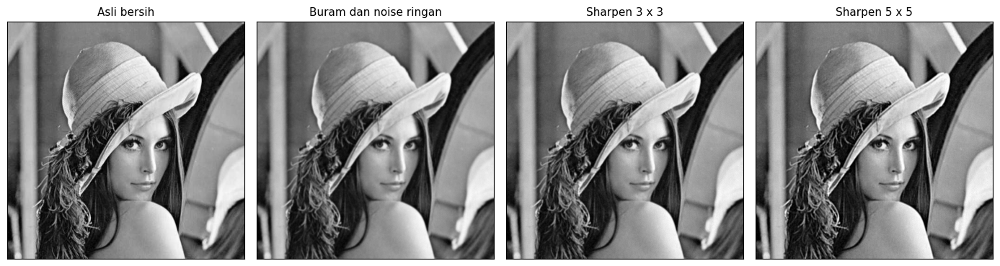

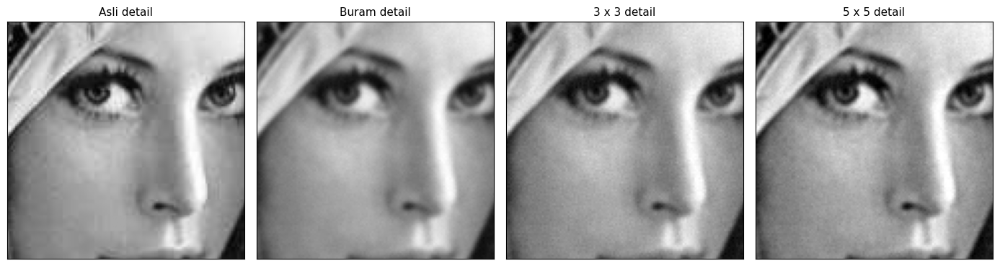

| Kondisi | MSE | PSNR dB | Gradien tepi | Sigma noise | Clipping % |
| --- | --- | --- | --- | --- | --- |
| Input buram | 50.3796 | 31.1083 | 145.7247 | 1.9973 | 0.0000 |
| Sharpen 3 x 3 | 38.9284 | 32.2281 | 168.2755 | 3.8246 | 0.1438 |
| Sharpen 5 x 5 | 34.1920 | 32.7916 | 197.8477 | 3.9344 | 0.8499 |

In [ ]:
def sharpening_kernel(n, alpha=1.0):
    identitas = np.zeros((n,n),np.float64)
    identitas[n//2,n//2] = 1
    return (1+alpha)*identitas - alpha*np.ones((n,n))/(n*n)

k3, k5 = sharpening_kernel(3), sharpening_kernel(5)
print('Kernel 3 x 3:\n',k3,'\nJumlah:',k3.sum())
print('Kernel 5 x 5:\n',k5,'\nJumlah:',k5.sum())
blurry_clean = cv.GaussianBlur(lena_gray.astype(np.float64),(5,5),1)
noise_gaussian = np.random.default_rng(2026).normal(0,2,lena_gray.shape)
blurry = np.clip(blurry_clean+noise_gaussian,0,255)
sharp3_raw = convolution2d(blurry,k3)
sharp5_raw = convolution2d(blurry,k5)
sharp3,sharp5 = u8(sharp3_raw),u8(sharp5_raw)

def grad_mag(image):
    f=image.astype(np.float64)
    gx=cv.Sobel(f,cv.CV_64F,1,0,ksize=3)
    gy=cv.Sobel(f,cv.CV_64F,0,1,ksize=3)
    return np.hypot(gx,gy)

grad_ref = grad_mag(lena_gray)
edge_mask = grad_ref > np.quantile(grad_ref,0.80)
edge_ref = float(grad_ref[edge_mask].mean())
clean_raw3 = convolution2d(blurry_clean,k3)
clean_raw5 = convolution2d(blurry_clean,k5)
sharp_rows=[]
for name,image,raw,clean in [('Input buram',u8(blurry),blurry,blurry_clean),
    ('Sharpen 3 x 3',sharp3,sharp3_raw,clean_raw3),('Sharpen 5 x 5',sharp5,sharp5_raw,clean_raw5)]:
    mse,psnr=mse_psnr(lena_gray,image)
    edge=float(grad_mag(image)[edge_mask].mean())
    # Selisih terhadap versi bersih dari proses yang sama mengukur noise terpropagasi.
    sigma=float(np.std((raw-clean)[3:-3,3:-3]))
    clipping=float(100*np.mean((raw<0)|(raw>255)))
    sharp_rows.append([name,mse,psnr,edge,sigma,clipping])
show_side_by_side([lena_gray,u8(blurry),sharp3,sharp5],
  ['Asli bersih','Buram dan noise ringan','Sharpen 3 x 3','Sharpen 5 x 5'],'T2_sharpen.png',ncols=4)
show_side_by_side([im[crop] for im in [lena_gray,u8(blurry),sharp3,sharp5]],
  ['Asli detail','Buram detail','3 x 3 detail','5 x 5 detail'],'T2_sharpen_detail.png',ncols=4)
tabel_markdown(['Kondisi','MSE','PSNR dB','Gradien tepi','Sigma noise','Clipping %'],sharp_rows)
print('Gradien rata-rata tepi citra acuan:',round(edge_ref,4))
print('Noise dihitung sebelum clipping, pada area tanpa batas 3 piksel.')
RINGKASAN['tugas2']={'hasil':sharp_rows,'gradien_tepi_acuan':edge_ref,
    'alpha':1,'noise_sigma_input':2,'blur_kernel':[5,5],'blur_sigma':1,
    'kernel3':k3.tolist(),'kernel5':k5.tolist()}

**Jawaban Tugas 2:** kernel yang lebih besar mengurangi komponen blur yang lebih luas, sehingga
pemulihan tepi dapat lebih kuat. Namun respons noise dan risiko overshoot juga harus diperhatikan.
Untuk penggunaan sehari-hari, **3 x 3 dipilih sebagai pilihan awal yang lebih konservatif** karena
area koreksinya kecil dan sigma noise yang terpropagasi lebih rendah. Pada citra uji ini, 5 x 5
dapat memberikan PSNR dan pemulihan tepi yang lebih baik; hasil angka tersebut tetap dilaporkan,
sehingga pilihan 3 x 3 bukan klaim bahwa ia selalu paling baik. Jika citra lebih buram dan noise
rendah, 5 x 5 dapat dipilih setelah inspeksi halo dan clipping. Gradien tinggi sendirian tidak
membuktikan kualitas tinggi, karena noise juga dapat menaikkan gradien.

## Tugas 3 Fungsi kustom kartun
Fungsi bernama `kartun(image)` menggabungkan Bilateral, Median pada grayscale, Adaptive Threshold,
dan operasi bitwise. Fungsi tidak mengubah array input.

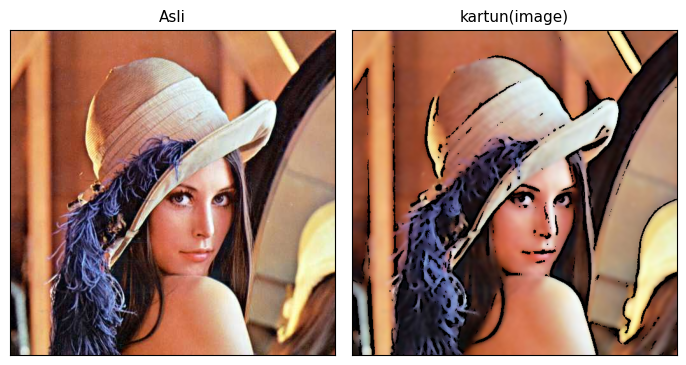

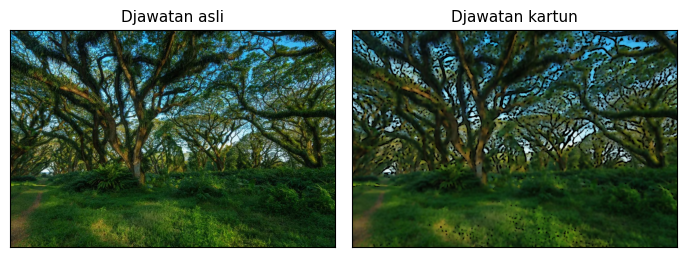

In [ ]:
def kartun(image):
    gray = cv.cvtColor(image,cv.COLOR_BGR2GRAY)
    gray_smooth = cv.medianBlur(gray,7)
    edges = cv.adaptiveThreshold(gray_smooth,255,cv.ADAPTIVE_THRESH_MEAN_C,
                                cv.THRESH_BINARY,9,9)
    color = cv.bilateralFilter(image,d=9,sigmaColor=200,sigmaSpace=200)
    return cv.bitwise_and(color,color,mask=edges)

hasil_kartun=kartun(lena)
assert hasil_kartun.shape == lena.shape and hasil_kartun.dtype == np.uint8
assert np.array_equal(hasil_kartun,cartoon_modul)
simpan_foto('T3_kartun_lena.png',hasil_kartun)
show_side_by_side([lena,hasil_kartun],['Asli','kartun(image)'],'T3_kartun.png')
# Tambahan: fungsi yang sama dapat dipakai pada foto lain.
kartun_djawatan=kartun(djawatan)
show_side_by_side([djawatan,kartun_djawatan],['Djawatan asli','Djawatan kartun'],'T3_kartun_djawatan.png')
RINGKASAN['tugas3']={'fungsi':'kartun(image)','shape':list(hasil_kartun.shape),
    'dtype':str(hasil_kartun.dtype),'sama_dengan_percobaan5':bool(np.array_equal(hasil_kartun,cartoon_modul))}

**Jawaban Tugas 3:** Bilateral meratakan warna tanpa mengaburkan semua batas. Adaptive Threshold
menghasilkan mask putih untuk area warna dan hitam untuk garis. `bitwise_and` mempertahankan
piksel warna hanya pada mask putih. Pada mask hitam, piksel menjadi hitam sehingga batas objek
lebih menonjol. Hasil berdampingan dan bukti kesesuaian fungsi ditampilkan di atas.

# Kesimpulan
Filter spasial mengubah citra berdasarkan piksel tetangga dan koefisien kernel. Low Pass
membantu menghaluskan gambar; Sharpen/High Pass menonjolkan perubahan intensitas.
Median lebih tepat untuk noise impuls dibandingkan Mean pada uji ini. Ukuran kernel Sharpen
perlu dipilih bersama kekuatan penajaman dan kadar noise. Feature map CNN yang belum dilatih
bergantung pada inisialisasi bobot. Efek Beauty, Vintage, Cartoon, Malam, Pagi, dan Kabut dapat
disusun melalui gabungan filter tradisional.

# Referensi
1. JTI Polinema. *Modul 6 - Spasial Filter*, bagian D, E, dan Tugas Praktikum, halaman 14 sampai 23.
2. OpenCV. Image Filtering. https://docs.opencv.org/4.13.0/d4/d86/group__imgproc__filter.html
3. OpenCV. Canny Edge Detection. https://docs.opencv.org/4.13.0/da/d22/tutorial_py_canny.html
4. OpenCV. Extended Image Processing Filters. https://docs.opencv.org/4.13.0/da/d17/group__ximgproc__filters.html
5. PyTorch. Conv2d. https://docs.pytorch.org/docs/2.6/generated/torch.nn.Conv2d.html

# Menyimpan dan mengunduh hasil
ZIP berisi semua gambar hasil, nilai mentah `.npy`, tabel ringkasan JSON, dan tiga foto asli.
Unduhan ZIP dijalankan melalui tombol berikut agar **Run all** tidak memicu unduhan otomatis.

In [ ]:
(HASIL/'ringkasan_hasil.json').write_text(json.dumps(RINGKASAN,indent=2,ensure_ascii=False),encoding='utf-8')
hasil_zip=WORK/'Hasil_Praktikum_Filter.zip'
with zipfile.ZipFile(hasil_zip,'w',zipfile.ZIP_DEFLATED) as z:
    for path in sorted(HASIL.iterdir()):
        if path.is_file():
            z.write(path,arcname='hasil_filter/'+path.name)
    for path in sorted(BASE.iterdir()):
        z.write(path,arcname='foto_asli/'+path.name)
print('Selesai:',len(list(HASIL.iterdir())),'berkas hasil. ZIP:',hasil_zip.name)
if IN_COLAB:
    import ipywidgets as widgets
    from google.colab import files
    tombol=widgets.Button(description='Unduh ZIP hasil',button_style='success')
    tombol.on_click(lambda _: files.download(str(hasil_zip)))
    display(tombol)
else:
    print('Notebook dijalankan pada Python lokal; ZIP tersedia di folder kerja.')

Selesai: 42 berkas hasil. ZIP: Hasil_Praktikum_Filter.zip
Notebook dijalankan pada Python lokal; ZIP tersedia di folder kerja.
